ILI SEIR

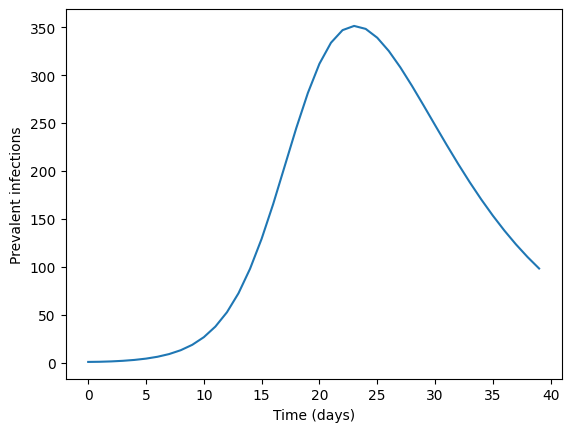

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

ili_data = pd.read_csv("./data/ili_data.csv")
hhs1_data = ili_data.loc[ ili_data.region == "hhs1" ].reset_index()
hhs1_data = hhs1_data.loc[:,['epiweek','ili']]
hhs1_s1 = hhs1_data.iloc[39:80]
hhs1_s1 = hhs1_s1.reset_index(drop=True)
hhs1_s1['time'] = np.arange(len(hhs1_s1))

n = 1000 
def seir(t,y, beta, sigma, gamma,n):
    s,e,i,r, c = y
    ds_dt = -beta*s*i/n
    de_dt = beta*s*i/n - sigma*e
    di_dt =  sigma*e - gamma*i
    dr_dt = gamma*i
    
    dc_dt = beta*s*i/n            
    return [ds_dt,de_dt, di_dt, dr_dt, dc_dt]


start,end = 0., 40


tvals = np.arange(start,end)


initial_conditions = (998,1 ,1, 0, 0)


beta, sigma, gamma = 3./2, 1/5.2 ,1./7


solution = solve_ivp( fun = seir
                     , t_span = (start,end)
                     , y0     = initial_conditions
                     , t_eval = tvals
                     , args   = (beta,sigma,gamma,n))
prevalent_infections = solution.y[2,:]
times                = solution.t 

plt.plot(times,prevalent_infections)
plt.xlabel("Time (days)")
plt.ylabel("Prevalent infections")
plt.show()


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.04140954925607023
        x: [ 5.376e+00  1.482e+00  4.784e+00  3.562e-01]
      nit: 52
      jac: [ 5.698e-03  3.584e-03 -9.592e-03  4.533e+03]
     nfev: 860
     njev: 172
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>


/var/folders/lx/dzcqck1n4yl7x9cr6hfzpn700000gp/T/ipykernel_71504/3430351945.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


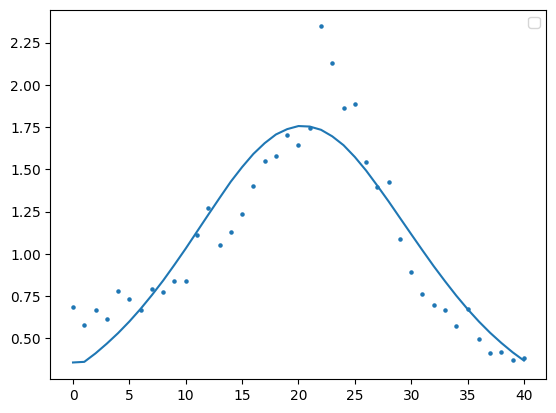

In [16]:
data = pd.DataFrame({"times":hhs1_s1['time'], "infections":hhs1_s1['ili']})

from scipy.optimize import minimize 
def SSE(params,data,n):                         #--lets assume n is fixed 
    beta,sigma,gamma, I0 = params                         #--"Unroll" parameters from the variable params
    #--Build our SIR model of the expected y
    
    #--SIR differential equations
    def seir(t,y, beta, sigma, gamma,n):
        s,e,i,r, c = y
        ds_dt = -beta*s*i/n
        de_dt = beta*s*i/n - sigma*e
        di_dt =  sigma*e - gamma*i
        dr_dt = gamma*i
    
        dc_dt = beta*s*i/n            
        return [ds_dt,de_dt, di_dt, dr_dt, dc_dt]
        
    #--inital conditions for s, i, r      Assume fixed for now
    initial_conditions = (998, 1,I0, 0., 0)

    start = min(data.times)
    end   = max(data.times) 
    
    solution = solve_ivp( fun = seir
                     , t_span = (start,end)
                     , y0     = initial_conditions
                     , t_eval = data.times.values  #<--evaluate our solution at all the x values we have in the data
                     , args   = (beta,sigma,gamma,n))
    prevalent_infections = solution.y[2,:]
    times                = solution.t 

    return np.mean( (prevalent_infections - data.infections.values)**2 ) #--Compute the SSE

results = minimize( lambda x: SSE(x,data=data,n=1000)
                   , x0=np.array([3,1,1, 2]) 
                   , bounds=[(0, None), (0,None), (0,None), (0,None)])
print(results)


beta,sigma,gamma, I0 = results.x

initial_conditions = (998,1,I0, 0., 0)

start = min(data.times)
end   = max(data.times) 

solution = solve_ivp( fun = seir
                 , t_span = (start,end)
                 , y0     = initial_conditions
                 , t_eval = data.times.values  #<--evaluate our solution at all the x values we have in the data
                 , args   = (beta, sigma, gamma,n))
prevalent_infections = solution.y[2,:]
times                = solution.t 

plt.scatter(data.times.values,data.infections.values,s=5)
plt.plot(times,prevalent_infections)
plt.legend()
plt.show()


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

mpox_data = pd.read_csv("./data/monkeypox.csv")

region_data = mpox_data.loc[mpox_data.country == "World"].reset_index(drop=True)
region_data = region_data[['epiweek', 'cases']]





mpox_s1 = region_data.iloc[10:60].reset_index(drop=True)
mpox_s1['time'] = np.arange(len(mpox_s1))

n = 1000 
def sir(t,y, beta, gamma,n):
    s,i,r, c = y
    ds_dt = -beta*s*i/n
    di_dt = beta*s*i/n - gamma*i
    dr_dt = gamma*i
    
    dc_dt = beta*s*i/n            
    return [ds_dt, di_dt, dr_dt, dc_dt]


start, end = 0., len(mpox_s1)


tvals = np.arange(start,end)


I0 = mpox_s1['cases'].iloc[0]
S0 = n - I0
R0 = 0

initial_conditions = (S0, I0, R0)


beta, gamma = 1.2, 1./14


solution = solve_ivp( fun = sir
                     , t_span = (start,end)
                     , y0     = initial_conditions
                     , t_eval = tvals
                     , args   = (beta,gamma,n))
infected             = solution.y[1, :]

plt.plot(times,infected)
plt.ylabel("Cases")
plt.show()

/var/folders/lx/dzcqck1n4yl7x9cr6hfzpn700000gp/T/ipykernel_71504/2452598705.py:6: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  mpox_data = pd.read_csv("./data/monkeypox.csv")


KeyError: "None of [Index(['epiweek', 'cases'], dtype='object')] are in the [columns]"

In [11]:
mpox_data = pd.read_csv("./data/monkeypox.csv")
region_data = mpox_data.loc[mpox_data.country == "World"].reset_index(drop=True)

region_data


/var/folders/lx/dzcqck1n4yl7x9cr6hfzpn700000gp/T/ipykernel_71504/1966489770.py:1: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  mpox_data = pd.read_csv("./data/monkeypox.csv")


,country,date,iso_code,total_cases,total_deaths,new_cases,new_deaths,new_cases_smoothed,new_deaths_smoothed,new_cases_per_million,total_cases_per_million,new_cases_smoothed_per_million,new_deaths_per_million,total_deaths_per_million,new_deaths_smoothed_per_million,suspected_cases_cumulative,annotation
0,World,2022-05-01,NaN,44.0,2.0,2.0,0.0,0.71,0.00,0.000,0.006,0.000,0.00000,0.00025,0.00000,NaN,NaN
1,World,2022-05-02,NaN,56.0,2.0,12.0,0.0,2.00,0.00,0.002,0.007,0.000,0.00000,0.00025,0.00000,NaN,NaN
2,World,2022-05-03,NaN,56.0,2.0,0.0,0.0,2.00,0.00,0.000,0.007,0.000,0.00000,0.00025,0.00000,NaN,NaN
3,World,2022-05-04,NaN,56.0,2.0,0.0,0.0,2.00,0.00,0.000,0.007,0.000,0.00000,0.00025,0.00000,NaN,NaN
4,World,2022-05-05,NaN,56.0,2.0,0.0,0.0,2.00,0.00,0.000,0.007,0.000,0.00000,0.00025,0.00000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1334,World,2025-12-25,NaN,173565.0,475.0,0.0,0.0,38.71,0.29,0.000,21.097,0.005,0.00000,0.05774,0.00004,NaN,NaN
1335,World,2025-12-26,NaN,173694.0,475.0,129.0,0.0,57.00,0.29,0.016,21.112,0.007,0.00000,0.05773,0.00004,NaN,NaN
1336,World,2025-12-27,NaN,173694.0,475.0,0.0,0.0,57.00,0.29,0.000,21.111,0.007,0.00000,0.05773,0.00004,NaN,NaN
1337,World,2025-12-28,NaN,173815.0,476.0,121.0,1.0,38.00,0.14,0.015,21.126,0.005,0.00012,0.05785,0.00002,NaN,NaN
